# Implementing forward and backward propagation methods for learing an XOR gate using a multi-layer neural network

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([0,1,1,0])

X = np.tile(X, (1000,1))
y = np.tile(y, 1000)

split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

In [3]:
def one_hot(y):
    return np.eye(2)[y]

y_train_oh = one_hot(y_train)
y_val_oh = one_hot(y_val)

In [ ]:
# Comparing sigmoid, tanh, relu as the activation functions.

In [4]:
def sigmoid(x): return 1/(1+np.exp(-x))
def sigmoid_deriv(x): return sigmoid(x)*(1-sigmoid(x))

def tanh(x): return np.tanh(x)
def tanh_deriv(x): return 1 - np.tanh(x)**2

def relu(x): return np.maximum(0,x)
def relu_deriv(x): return (x>0).astype(float)


def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    return -np.mean(np.sum(y_true*np.log(y_pred+1e-9), axis=1))

In [ ]:
# Implementing a deep multi layer perceptron (forward and backward propagation)

In [5]:
class DeepMLP:
    def __init__(self, layers, activation='relu'):
        self.L = len(layers) - 1
        self.W = {}
        self.b = {}

        for l in range(1, self.L+1):
            self.W[l] = np.random.randn(layers[l-1], layers[l]) * 0.5
            self.b[l] = np.zeros((1, layers[l]))

        if activation == 'sigmoid':
            self.act = sigmoid
            self.act_deriv = sigmoid_deriv
        elif activation == 'tanh':
            self.act = tanh
            self.act_deriv = tanh_deriv
        else:
            self.act = relu
            self.act_deriv = relu_deriv

    def forward(self, X):
        self.A = {0: X}
        self.Z = {}

        for l in range(1, self.L):
            self.Z[l] = self.A[l-1] @ self.W[l] + self.b[l]
            self.A[l] = self.act(self.Z[l])

        self.Z[self.L] = self.A[self.L-1] @ self.W[self.L] + self.b[self.L]
        self.A[self.L] = softmax(self.Z[self.L])

        return self.A[self.L]

    def backward(self, Y, lr=0.05):
        m = Y.shape[0]
        dZ = {}

        dZ[self.L] = self.A[self.L] - Y

        for l in reversed(range(1, self.L+1)):
            dW = self.A[l-1].T @ dZ[l] / m
            db = np.sum(dZ[l], axis=0, keepdims=True) / m

            self.W[l] -= lr * dW
            self.b[l] -= lr * db

            if l > 1:
                dA_prev = dZ[l] @ self.W[l].T
                dZ[l-1] = dA_prev * self.act_deriv(self.Z[l-1])

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

In [6]:
def accuracy(model, X, y):
    return np.mean(model.predict(X) == y)

In [7]:
def train(model, epochs=200):
    t_loss, v_loss = [], []

    for epoch in range(epochs):
        y_pred = model.forward(X_train)
        loss = cross_entropy(y_train_oh, y_pred)

        model.backward(y_train_oh)

        val_pred = model.forward(X_val)
        val_l = cross_entropy(y_val_oh, val_pred)

        t_loss.append(loss)
        v_loss.append(val_l)

    return t_loss, v_loss

In [8]:
def convergence_epoch(loss):
    for i in range(1, len(loss)):
        if abs(loss[i] - loss[i-1]) < 1e-4:
            return i
    return len(loss)


Training with SIGMOID


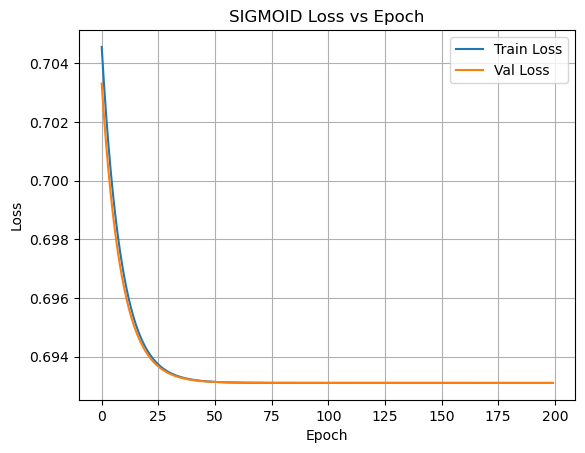


Training with TANH


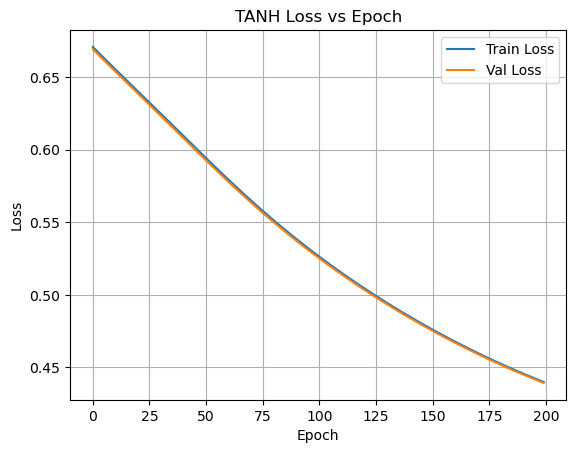


Training with RELU


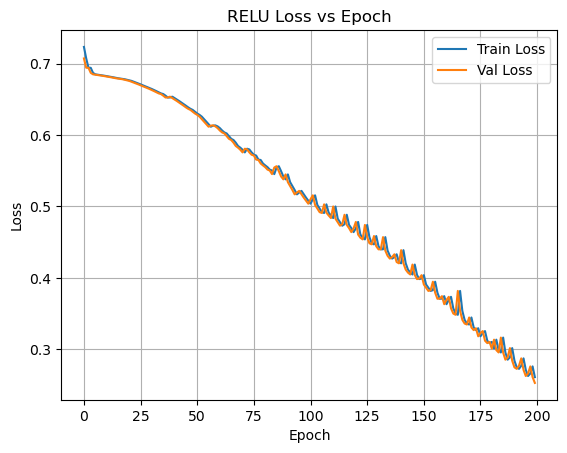

In [9]:
layers = [2, 8, 6, 4, 2]

activations = ['sigmoid', 'tanh', 'relu']
results = {}

for act in activations:
    print(f"\nTraining with {act.upper()}")

    model = DeepMLP(layers, activation=act)
    t_loss, v_loss = train(model)

    train_acc = accuracy(model, X_train, y_train)
    val_acc = accuracy(model, X_val, y_val)
    final_loss = v_loss[-1]
    conv = convergence_epoch(v_loss)

    results[act] = (train_acc, val_acc, final_loss, conv)


    plt.figure()
    plt.plot(t_loss, label="Train Loss")
    plt.plot(v_loss, label="Val Loss")
    plt.title(f"{act.upper()} Loss vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

In [10]:
print("Activation | Train Acc | Val Acc | Loss | Convergence")

for act in results:
    r = results[act]
    print(f"{act:8} | {r[0]:.4f} | {r[1]:.4f} | {r[2]:.4f} | {r[3]}")

Activation | Train Acc | Val Acc | Loss | Convergence
sigmoid  | 0.5000 | 0.5000 | 0.6931 | 22
tanh     | 0.7500 | 0.7500 | 0.4393 | 200
relu     | 0.7500 | 0.7500 | 0.2529 | 37
